In [ ]:
import requests
import pandas as pd
import json
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
url = 'https://icedapi.niti.gov.in/v1/gen-metatable-data'

headers = {
    "accept": "application/json, text/plain, */*",
    "accept-language": "en-GB,en;q=0.9",
    "content-type": "application/json",
    "origin": "https://iced.niti.gov.in",
    "priority": "u=1, i",
    "referer": "https://iced.niti.gov.in/",
    "user-agent": "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/153.0.0.0 Safari/537.36"
}

payload = {
    "source": "solar",
    "rangeType": "monthly"
}


response = requests.post(url=url, headers=headers, json=payload)

print(f'Status code: {response.status_code}')

data = response.json()

if isinstance(data, list):
    df = pd.DataFrame(data)

df.to_csv('../data/raw/niti_aayog/solar-gen-trends-15to26.csv', index=False)

Status code: 200


In [45]:
print(df.describe())
print(df.info())

        generation
count  5256.000000
mean    168.448927
std     516.024690
min       0.000000
25%       0.010000
50%       1.935000
75%      80.297500
max    6767.100000
<class 'pandas.DataFrame'>
RangeIndex: 5256 entries, 0 to 5255
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   source      5256 non-null   str    
 1   state       5256 non-null   str    
 2   generation  5256 non-null   float64
 3   year        5256 non-null   str    
 4   month       5256 non-null   str    
dtypes: float64(1), str(4)
memory usage: 352.5 KB
None


Text(0, 0.5, 'Power GWh')

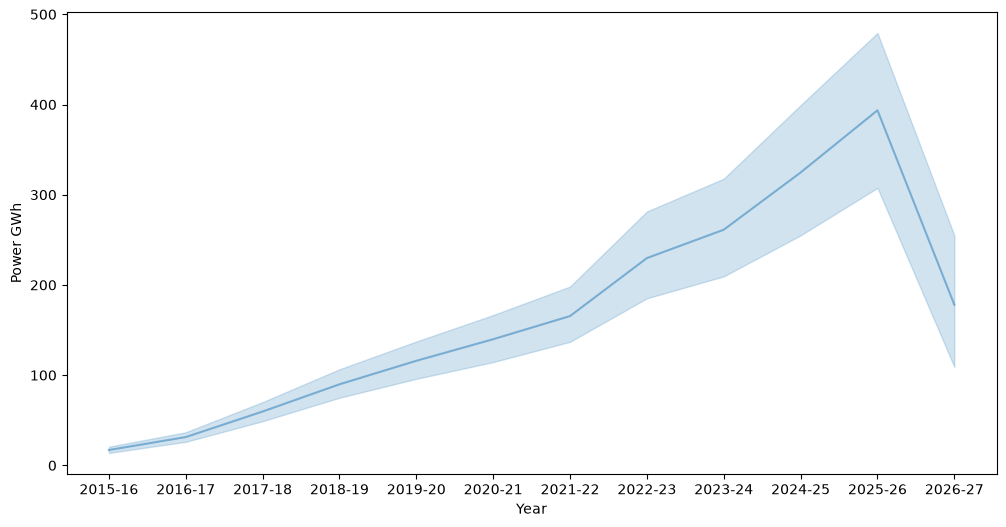

In [ ]:



plt.figure(figsize=(12,6))
sns.lineplot(x=df['year'], y=df['generation'], alpha=0.5)
plt.xlabel('Year')
plt.ylabel('Power GWh')